In [13]:
import importlib
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.nn.utils import parameters_to_vector

from common import local_rlct_estimater
import objective_function.gelu_dnn as gelu_dnn

importlib.reload(local_rlct_estimater)
importlib.reload(gelu_dnn)

LocalRLCTTorchEstimator = local_rlct_estimater.LocalRLCTTorchEstimator
make_true_model = gelu_dnn.make_true_model
make_learning_model = gelu_dnn.make_learning_model
sample_from_true_model = gelu_dnn.sample_from_true_model

plt.style.use("ggplot")
dtype = torch.float32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(dtype)

print(device)


cuda


In [14]:
torch.manual_seed(0)
np.random.seed(0)

# Model architecture.
input_dim = 2
output_dim = 1
true_hidden_dims = (12, 12)
learning_hidden_dims = (12, 12)

# Dataset sizes. We keep the training set small enough so interpolation is easy.
n_train = 1000
n_test = 1000
noise_std = 0.0

# Training settings.
# minibatch_sizes = [8, 16, 32]
minibatch_sizes = [8]
n_trials_per_batch = 20
optimizer_lr = 5e-3
max_epochs = 12000
min_epochs = 50
check_interval = 50
train_tol = 1e-5  # accept solutions with sufficiently small training loss
lr_decay = 0.5
max_restarts = 3

# RLCT estimation settings.
rlct_betas = [4, 8, 16, 32]
rlct_step_size = 5e-5
rlct_n_steps = 600
rlct_burn_in = 100
rlct_thinning = 10
rlct_n_chains = 2
rlct_clip_radius = 1.0
rlct_grad_clip = 75.0
rlct_max_beta_step = 0.05

print(f"device: {device}")
print(f"dtype: {dtype}")
print(f"true architecture: {input_dim} -> {true_hidden_dims} -> {output_dim}")
print(f"learning architecture: {input_dim} -> {learning_hidden_dims} -> {output_dim}")
print(f"train/test sizes: {n_train}/{n_test}")
print(f"minibatch sizes: {minibatch_sizes}")
print(f"minimum training epochs: {min_epochs}")


device: cuda
dtype: torch.float32
true architecture: 2 -> (12, 12) -> 1
learning architecture: 2 -> (12, 12) -> 1
train/test sizes: 1000/1000
minibatch sizes: [8]
minimum training epochs: 50


In [15]:
true_model_for_count = make_true_model(
    input_dim=input_dim,
    hidden_dims=true_hidden_dims,
    output_dim=output_dim,
    dtype=dtype,
)
learning_model_for_count = make_learning_model(
    input_dim=input_dim,
    hidden_dims=learning_hidden_dims,
    output_dim=output_dim,
    dtype=dtype,
)

true_num_params = sum(param.numel() for param in true_model_for_count.parameters())
learning_num_params = sum(param.numel() for param in learning_model_for_count.parameters())

print(f"true model parameter count: {true_num_params}")
print(f"learning model parameter count: {learning_num_params}")


true model parameter count: 205
learning model parameter count: 205


In [16]:
true_model = make_true_model(
    input_dim=input_dim,
    hidden_dims=true_hidden_dims,
    output_dim=output_dim,
    dtype=dtype,
)
true_model = true_model.to(device=device, dtype=dtype)
true_model.eval()
for parameter in true_model.parameters():
    parameter.requires_grad_(False)

x_train = torch.empty(n_train, input_dim, dtype=dtype, device=device).uniform_(-2.0, 2.0)
x_test = torch.empty(n_test, input_dim, dtype=dtype, device=device).uniform_(-2.0, 2.0)
y_train_true, y_train = sample_from_true_model(true_model, x_train, noise_std=noise_std)
y_test_true, y_test = sample_from_true_model(true_model, x_test, noise_std=noise_std)

print(f"x_train shape: {tuple(x_train.shape)}")
print(f"y_train shape: {tuple(y_train.shape)}")
print(f"x_test shape: {tuple(x_test.shape)}")
print(f"y_test shape: {tuple(y_test.shape)}")
print(f"x_train device: {x_train.device}")
print("first 3 train samples:")
for i in range(3):
    print(f"x={x_train[i].detach().cpu().tolist()}")
    print(f"y={y_train[i].detach().cpu().tolist()}")


x_train shape: (1000, 2)
y_train shape: (1000, 1)
x_test shape: (1000, 2)
y_test shape: (1000, 1)
x_train device: cuda:0
first 3 train samples:
x=[-0.40381407737731934, 0.06671667098999023]
y=[-0.02673601359128952]
x=[-1.9002784490585327, 1.7603175640106201]
y=[0.0048762112855911255]
x=[1.783416509628296, 1.186924934387207]
y=[-0.24882355332374573]


In [17]:
def mse_loss(model, xb, yb):
    return torch.mean((model(xb) - yb) ** 2)


def rankdata(values):
    values = np.asarray(values)
    order = np.argsort(values)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(values.size, dtype=float)
    return ranks


def train_until_zero_train_error(minibatch_size, seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    model = make_learning_model(
        input_dim=input_dim,
        hidden_dims=learning_hidden_dims,
        output_dim=output_dim,
        dtype=dtype,
    )
    model = model.to(device=device, dtype=dtype)
    history = []
    n_items = x_train.shape[0]
    total_epochs = 0
    best_train_loss = math.inf
    current_lr = optimizer_lr

    for restart in range(max_restarts + 1):
        optimizer = torch.optim.Adam(model.parameters(), lr=current_lr)

        for epoch in range(1, max_epochs + 1):
            permutation = torch.randperm(n_items, device=device)
            for start in range(0, n_items, minibatch_size):
                batch_indices = permutation[start : start + minibatch_size]
                xb = x_train[batch_indices]
                yb = y_train[batch_indices]

                optimizer.zero_grad()
                loss = mse_loss(model, xb, yb)
                loss.backward()
                optimizer.step()

            total_epochs += 1

            if epoch % check_interval == 0 or (restart == 0 and epoch == 1):
                with torch.no_grad():
                    train_loss = mse_loss(model, x_train, y_train).item()
                best_train_loss = min(best_train_loss, train_loss)
                history.append((total_epochs, train_loss, current_lr))
                if total_epochs >= min_epochs and train_loss <= train_tol:
                    return model, history, total_epochs, train_loss

        current_lr *= lr_decay

    with torch.no_grad():
        final_train_loss = mse_loss(model, x_train, y_train).item()
    best_train_loss = min(best_train_loss, final_train_loss)

    raise RuntimeError(
        f"Did not reach numerical zero train loss. minibatch_size={minibatch_size}, "
        f"seed={seed}, final_train_loss={final_train_loss:.3e}, best_train_loss={best_train_loss:.3e}"
    )


def estimate_local_rlct(model, minibatch_size, seed):
    w0 = parameters_to_vector([param.detach().clone() for param in model.parameters()])
    estimator = LocalRLCTTorchEstimator.from_tensors(
        model,
        mse_loss,
        x_train,
        y_train,
        w0=w0,
        device=device,
        dtype=dtype,
        eval_mode=True,
    )
    return estimator.estimate(
        betas=rlct_betas,
        step_size=rlct_step_size,
        n_steps=rlct_n_steps,
        burn_in=rlct_burn_in,
        thinning=rlct_thinning,
        clip_radius=rlct_clip_radius,
        grad_clip=rlct_grad_clip,
        n_chains=rlct_n_chains,
        max_beta_step=rlct_max_beta_step,
        regression_tail=None,
        use_weighted_regression=True,
        update_batch_size=min(minibatch_size, x_train.shape[0]),
        seed=seed,
    )


In [18]:
records = []

for minibatch_size in minibatch_sizes:
    for trial in range(n_trials_per_batch):
        seed = 1000 * minibatch_size + trial
        model, history, epochs_run, train_loss = train_until_zero_train_error(
            minibatch_size=minibatch_size,
            seed=seed,
        )

        with torch.no_grad():
            test_loss = mse_loss(model, x_test, y_test).item()

        generalization_gap = abs(test_loss - train_loss)

        rlct_result = estimate_local_rlct(
            model=model,
            minibatch_size=minibatch_size,
            seed=seed,
        )

        record = {
            "minibatch_size": minibatch_size,
            "trial": trial,
            "seed": seed,
            "epochs_run": epochs_run,
            "train_loss": train_loss,
            "test_loss": test_loss,
            "generalization_gap": generalization_gap,
            "lambda_hat": rlct_result.lambda_hat,
            "betaEf": rlct_result.betaEf.copy(),
            "betaEf_se": rlct_result.betaEf_se.copy(),
        }
        records.append(record)

        print(
            f"batch={minibatch_size:>3} trial={trial} epochs={epochs_run:>5} "
            f"train_loss={train_loss:.3e} test_loss={test_loss:.3e} |gap|={generalization_gap:.3e} "
            f"lambda_hat={rlct_result.lambda_hat:.4f}"
        )

generalization_gaps = np.array([record["generalization_gap"] for record in records], dtype=float)
lambda_hats = np.array([record["lambda_hat"] for record in records], dtype=float)
batch_labels = np.array([record["minibatch_size"] for record in records], dtype=int)
pearson_corr = float(np.corrcoef(generalization_gaps, lambda_hats)[0, 1])
spearman_corr = float(np.corrcoef(rankdata(generalization_gaps), rankdata(lambda_hats))[0, 1])

print()
print(f"pearson correlation: {pearson_corr:.4f}")
print(f"spearman correlation: {spearman_corr:.4f}")


batch=  8 trial=0 epochs=  100 train_loss=1.363e-07 test_loss=1.188e-07 |gap|=1.747e-08 lambda_hat=5.4414
batch=  8 trial=1 epochs=   50 train_loss=1.369e-06 test_loss=1.475e-06 |gap|=1.059e-07 lambda_hat=7.8579
batch=  8 trial=2 epochs=   50 train_loss=3.567e-06 test_loss=3.670e-06 |gap|=1.030e-07 lambda_hat=6.0962
batch=  8 trial=3 epochs=   50 train_loss=2.026e-06 test_loss=2.005e-06 |gap|=2.093e-08 lambda_hat=5.4680
batch=  8 trial=4 epochs=   50 train_loss=3.833e-07 test_loss=4.236e-07 |gap|=4.031e-08 lambda_hat=6.2327
batch=  8 trial=5 epochs=   50 train_loss=8.498e-06 test_loss=8.566e-06 |gap|=6.743e-08 lambda_hat=4.9100
batch=  8 trial=6 epochs=   50 train_loss=7.254e-07 test_loss=8.619e-07 |gap|=1.365e-07 lambda_hat=5.0885
batch=  8 trial=7 epochs=   50 train_loss=9.973e-07 test_loss=9.384e-07 |gap|=5.892e-08 lambda_hat=5.3169
batch=  8 trial=8 epochs=  100 train_loss=1.652e-06 test_loss=1.719e-06 |gap|=6.699e-08 lambda_hat=4.6802
batch=  8 trial=9 epochs=   50 train_loss=3.65

In [19]:
def iqr_inlier_mask(values, whisker_width=1.5):
    values = np.asarray(values, dtype=float)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    iqr = q3 - q1
    lower = q1 - whisker_width * iqr
    upper = q3 + whisker_width * iqr
    return (values >= lower) & (values <= upper)

filtered_generalization_gaps = np.array(
    [record["generalization_gap"] for record in records],
    dtype=float,
)
filtered_lambda_hats = np.array(
    [record["lambda_hat"] for record in records],
    dtype=float,
)
filtered_batch_labels = np.array(
    [record["minibatch_size"] for record in records],
    dtype=int,
)

gap_mask = iqr_inlier_mask(filtered_generalization_gaps)
lambda_mask = iqr_inlier_mask(filtered_lambda_hats)
inlier_mask = gap_mask & lambda_mask

filtered_generalization_gaps = filtered_generalization_gaps[inlier_mask]
filtered_lambda_hats = filtered_lambda_hats[inlier_mask]
filtered_batch_labels = filtered_batch_labels[inlier_mask]
filtered_records = [record for record, keep in zip(records, inlier_mask) if keep]

filtered_pearson_corr = float(np.corrcoef(filtered_generalization_gaps, filtered_lambda_hats)[0, 1])
filtered_spearman_corr = float(
    np.corrcoef(rankdata(filtered_generalization_gaps), rankdata(filtered_lambda_hats))[0, 1]
)

print(f"used {len(filtered_records)} inliers out of {len(records)} runs")
print(f"pearson correlation: {filtered_pearson_corr:.4f}")
print(f"spearman correlation: {filtered_spearman_corr:.4f}")


used 17 inliers out of 20 runs
pearson correlation: 0.1555
spearman correlation: 0.0833


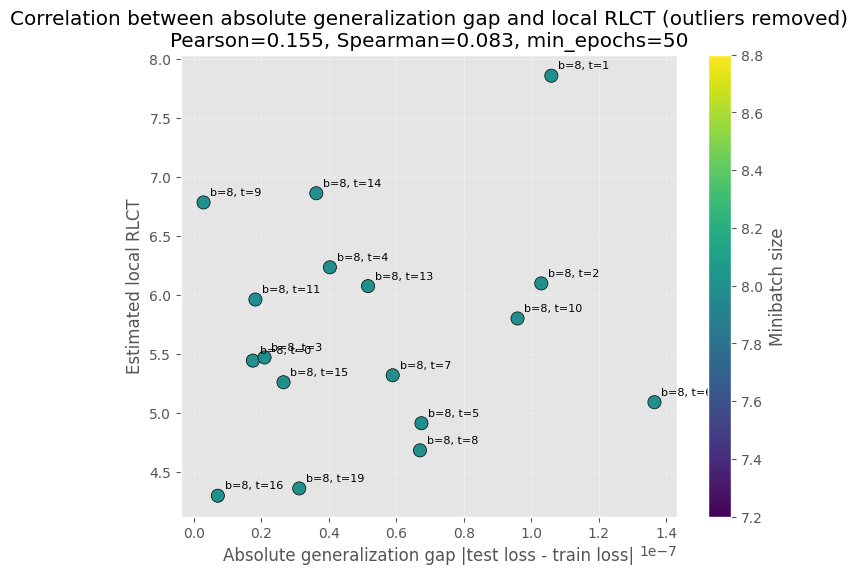

{8: {'mean_generalization_gap': 5.218659825847199e-08,
  'mean_lambda_hat': 5.6751530367906335,
  'n_inliers': 17}}

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    filtered_generalization_gaps,
    filtered_lambda_hats,
    c=filtered_batch_labels,
    cmap="viridis",
    s=90,
    edgecolor="black",
    linewidth=0.5,
)

for record in filtered_records:
    ax.annotate(
        f"b={record['minibatch_size']}, t={record['trial']}",
        (record["generalization_gap"], record["lambda_hat"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8,
    )

ax.set_xlabel("Absolute generalization gap |test loss - train loss|")
ax.set_ylabel("Estimated local RLCT")
ax.set_title(
    "Correlation between absolute generalization gap and local RLCT (outliers removed)\n"
    f"Pearson={filtered_pearson_corr:.3f}, Spearman={filtered_spearman_corr:.3f}, min_epochs={min_epochs}"
)
ax.grid(True, alpha=0.3)

colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label("Minibatch size")
plt.show()

summary = {}
for minibatch_size in minibatch_sizes:
    batch_records = [record for record in filtered_records if record["minibatch_size"] == minibatch_size]
    if batch_records:
        summary[minibatch_size] = {
            "mean_generalization_gap": float(np.mean([record["generalization_gap"] for record in batch_records])),
            "mean_lambda_hat": float(np.mean([record["lambda_hat"] for record in batch_records])),
            "n_inliers": len(batch_records),
        }

summary
